In [36]:
"""
The purpose of this Jupyter notebook is to generate figures for training
metrics logged while fine-tuning the xCAPT5 MLP head on the
VACV-specific PPI data set.
"""

'\nThe purpose of this Jupyter notebook is to generate figures for training\nmetrics logged while fine-tuning the xCAPT5 MLP head on the\nVACV-specific PPI data set.\n'

In [37]:
import os

import pandas as pd
import matplotlib as mpl
from matplotlib import pyplot as plt

# Defining a Function for Figure Generation

In [46]:
# For the sake of convenience, define a function for figure generation
def generate_figs(curve_data_dir, col_template):
    """
    Generates a figure for four different training metrics: training
    loss, validation loss, validation AUROC and validation PR AUC.

    Parameters
    ----------
    curve_data_dir: str
        A string denoting the directory the curve data is stored in. The
        directory is expected to contain four different CSV files, one
        for each training metric.
    col_template: str
        A string specifying the template of the column names to use for
        visualization. It has to be in a general way such that it can be
        used as f-string (i.e. contain curly braces).

    Returns
    -------
    None
    """
    # Load a colormap for assigning colors to the individual curves in
    # the plot
    colors = mpl.colormaps["tab10"].colors

    # Define settings specific to the individual metrics
    metric_settings = {
        "train_loss": {"y_label": "Training loss", "upper_y_lim": None},
        "val_loss": {"y_label": "Validation loss", "upper_y_lim": None},
        "roc_auc": {"y_label": "AUROC", "upper_y_lim": 1},
        "pr_auc": {"y_label": "PR AUC", "upper_y_lim": 1}
    }

    files_in_dir = os.listdir(curve_data_dir)

    for file in files_in_dir:
        # Logically, skipt non-CSV files
        if os.path.splitext(file)[1] != ".csv":
            continue
        
        # Load the current file into a Pandas DataFrame
        current_df = pd.read_csv(
            os.path.join(curve_data_dir, file)
        )

        fig, ax = plt.subplots(1, 1)

        if "roc_auc" in file:
            current_settings = metric_settings["roc_auc"]
            current_metric = "roc_auc"
        elif "pr_auc" in file:
            current_settings = metric_settings["pr_auc"]
            current_metric = "pr_auc"
        elif "train_loss" in file:
            current_settings = metric_settings["train_loss"]
            current_metric = "train_loss"
        else:
            current_settings = metric_settings["val_loss"]
            current_metric = "val_loss"

        ax.set_xlabel("Epoch", fontsize=18)
        ax.set_ylabel(current_settings["y_label"], fontsize=18)

        # Iterate over the columns corresponding to the individual seeds
        # and plot them
        for i, color in zip(range(5), colors):
            current_seed_col = col_template.format(
                seed = i, metric = current_metric
            )

            ax.plot(
                range(1, 101),
                current_df[current_seed_col],
                lw=2,
                color=color,
                label=f"Seed {i}"
            )
        
        # Since I'm using `None` to define axis limits, the `set_ylim()`
        # call has to appear after plotting
        # The reason for that is the following: Using `None` for the
        # upper limit sets the limit to the current autoscaled upper
        # limit
        # However, no data has been plotted yet, which is why the
        # autoscaled limits are still the default (0, 1)
        # Thus, the upper y-limit is set to 1
        # When moving `set_ylim()` after the plotting loop, the upper
        # y-limit is autoscaled from the data
        ax.set_xlim(0, 100) # Training was performed for 100 epochs
        ax.set_ylim(0, current_settings["upper_y_lim"])

        ax.tick_params(axis="both", labelsize=13)
        
        ax.legend(loc="best", fontsize=13)

        # Save the current figure both as PNG and as SVG
        fig.savefig(
            os.path.join(curve_data_dir, f"{current_metric}.png"),
            dpi=300
        )
        fig.savefig(
            os.path.join(curve_data_dir, f"{current_metric}.svg")
        )

# Generate Figures for the Sled Checkpoint

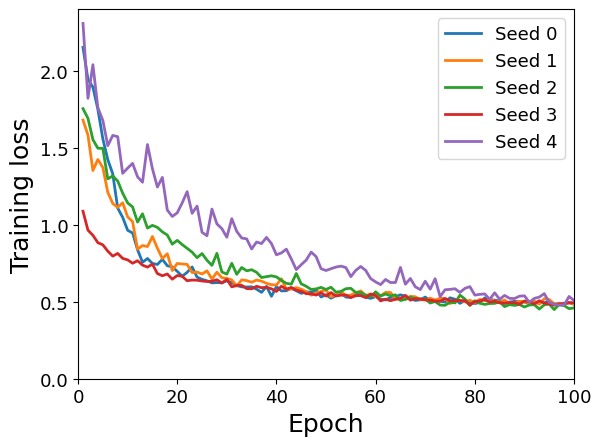

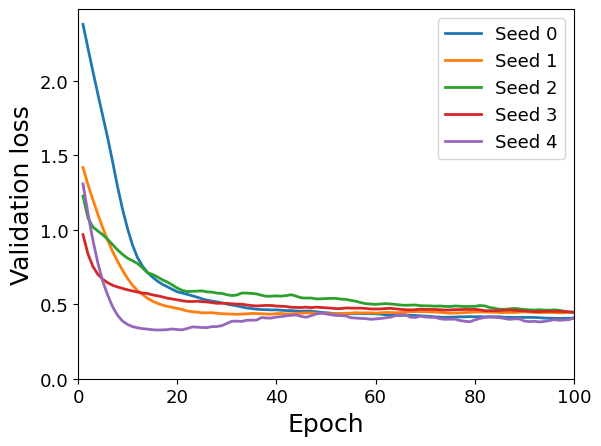

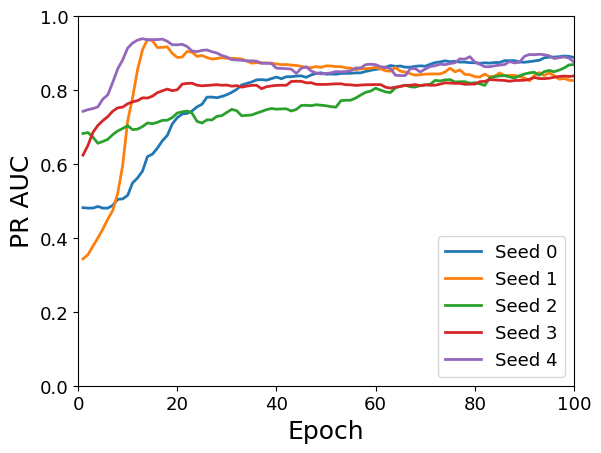

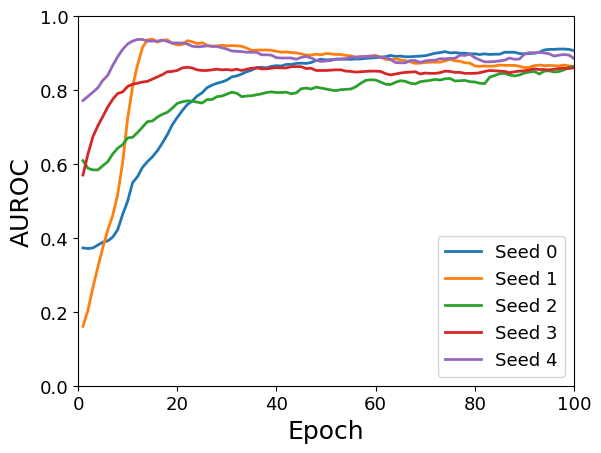

In [ ]:
sled_dir = "training_metrics_Sled"

generate_figs(
    sled_dir,
    "ordinary_loss_Sled_100_epochs_seed_{seed} - {metric}"
)

# Generate Figures for the Pan checkpoint

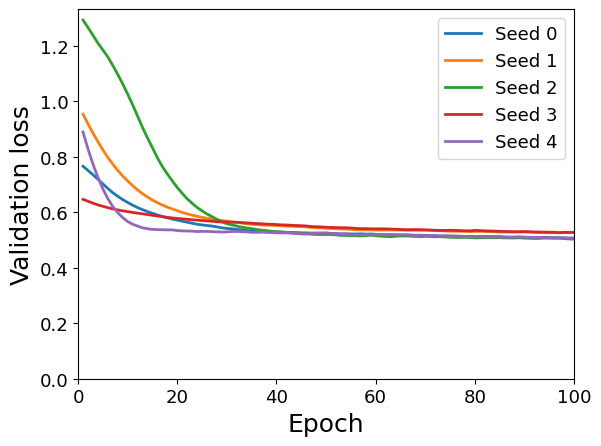

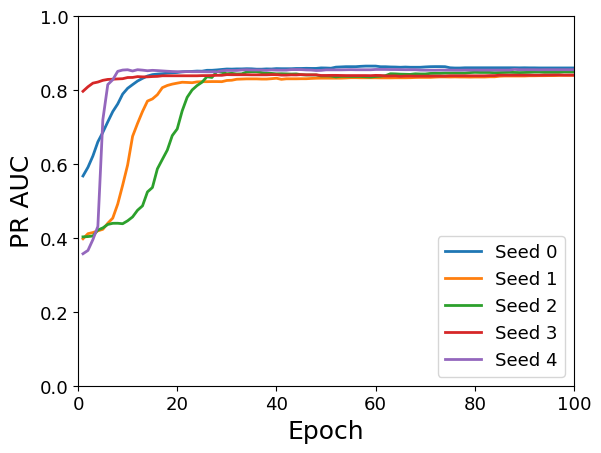

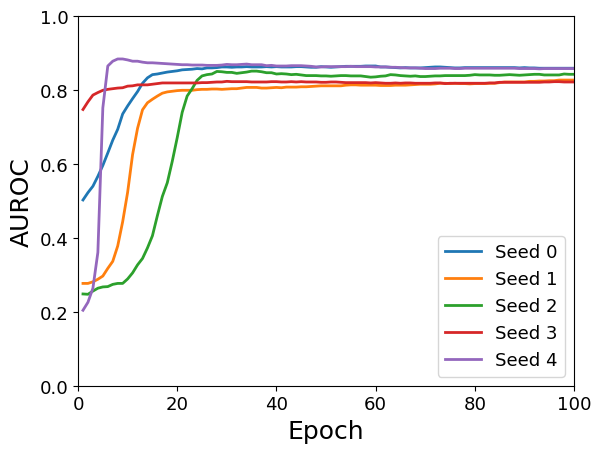

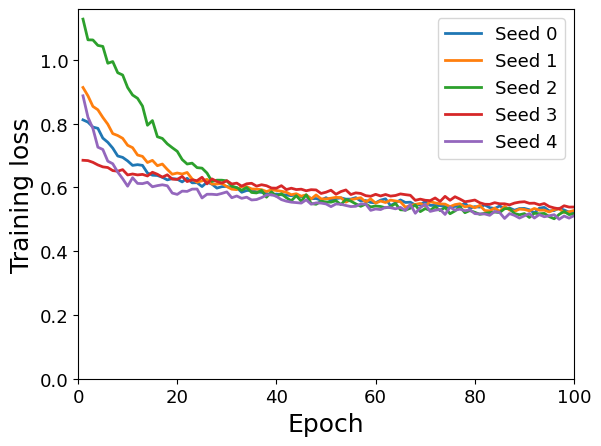

In [49]:
pan_dir = "training_metrics_Pan"

generate_figs(
    pan_dir,
    "ordinary_loss_Pan_100_epochs_seed_{seed} - {metric}"
)